<a href="https://colab.research.google.com/github/banotahira0915-bano/Colab--amlcodes/blob/main/Exp4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


===== OvR - Logistic Regression =====
Accuracy : 0.9666666666666667
F1 Score : 0.9658994032395567
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.89      0.94         9
           2       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30


===== OvO - Logistic Regression =====
Accuracy : 1.0
F1 Score : 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


===== OvR - SVM =====

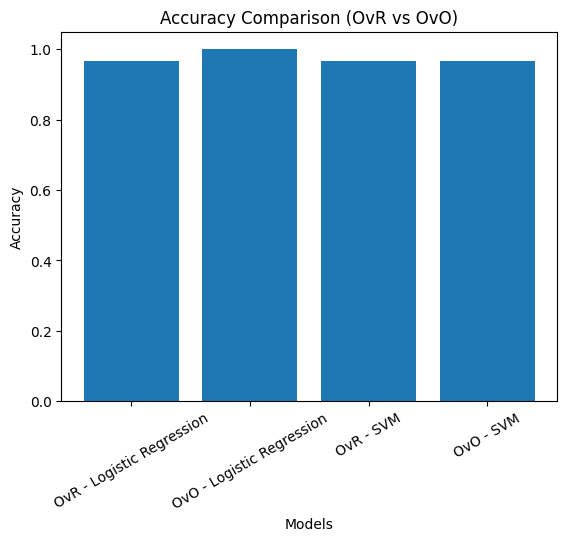

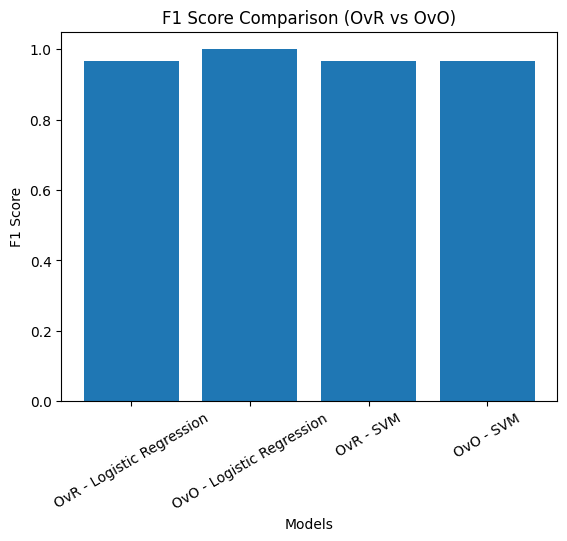

In [ ]:
# ================================
# 1. Import Libraries
# ================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# ================================
# 2. Load Multi-class Dataset
# ================================
data = load_iris()

X = data.data
y = data.target

# ================================
# 3. Train-Test Split
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================================
# 4. Feature Scaling
# ================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ================================
# 5. Define Models
# ================================
# Base models
lr = LogisticRegression(max_iter=200)
svm = SVC(kernel='linear')

# OvR Models
ovr_lr = OneVsRestClassifier(lr)
ovr_svm = OneVsRestClassifier(svm)

# OvO Models
ovo_lr = OneVsOneClassifier(lr)
ovo_svm = OneVsOneClassifier(svm)

# ================================
# 6. Train Models
# ================================
models = {
    "OvR - Logistic Regression": ovr_lr,
    "OvO - Logistic Regression": ovo_lr,
    "OvR - SVM": ovr_svm,
    "OvO - SVM": ovo_svm
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')  # macro for multi-class

    results.append([name, acc, f1])

    print(f"\n===== {name} =====")
    print("Accuracy :", acc)
    print("F1 Score :", f1)
    print("Classification Report:\n", classification_report(y_test, y_pred))

# ================================
# 7. Comparison Table
# ================================
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1 Score"])

print("\n===== MODEL COMPARISON =====")
print(results_df)

# ================================
# 8. Plot Accuracy Comparison
# ================================
plt.figure()
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.xticks(rotation=30)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison (OvR vs OvO)")
plt.show()

# ================================
# 9. Plot F1 Score Comparison
# ================================
plt.figure()
plt.bar(results_df["Model"], results_df["F1 Score"])
plt.xticks(rotation=30)
plt.xlabel("Models")
plt.ylabel("F1 Score")
plt.title("F1 Score Comparison (OvR vs OvO)")
plt.show()